In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

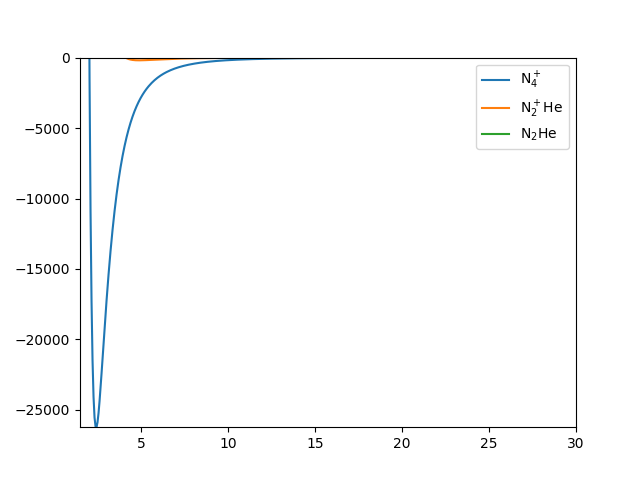

In [2]:
# Define potentials 
from tbr.potentials import LJ, dLJ
from tbr.constants import ANG2BOH, K2HAR

# N4p_de = 52.2 kcal/mol
N4p_de = 0.083186 # (Eh)
N4p_re = 1.382*ANG2BOH # (A -> a0)
N2_alpha = 1.710 # A^3
N4p_c4 = N2_alpha*(ANG2BOH**3)/2 # C4 = alpha/2
N4p_c8 = N4p_c4**2/(4*N4p_de)

# J. Chem. Phys., Vol. 95, No.8, 15 October 1991
# doi: 10.1063/1.461604
# ESMSV potential
N2He_de =  2.15*0.0000367493 # (meV -> Eh)
N2He_re = 3.66*ANG2BOH # (A -> a0)

N2He_c6 = 6093*(3.67493e-5)*ANG2BOH**6 # (meV A^6 -> Eh*a0^6)
N2He_c12 =  N2He_c6**2/(4*N2He_de)

N2pHe_de = 133.12*0.0000046 # cm^-1 -> Eh
N2pHe_re = 6.199
He_alpha = 0.208 # A^3
N2pHe_c4 = He_alpha*ANG2BOH**3/2 
N2pHe_c8 = N2pHe_c4**2/(4*N2pHe_de)

N4_de = 173.9 # kcal/mol
N4_re = 1.386*ANG2BOH # (A)
N4_c6 = 1
N4_c12 = 1

v_N4p = LJ(n=4, m=8, cn = N4p_c4, cm = N4p_c8)
dv_N4p = dLJ(n=4, m=8, cn = N4p_c4, cm = N4p_c8)

v_N2He = LJ(n=6, m=12, cn = N2He_c6, cm = N2He_c12)
dv_N2He = dLJ(n=6, m=12, cn = N2He_c6, cm = N2He_c12)

v_N2pHe = LJ(n=4, m=8, cn = N2pHe_c4, cm = N2pHe_c8)
dv_N2pHe = dLJ(n=4, m=8, cn = N2pHe_c4, cm = N2pHe_c8)

# N2 + N2p + He
v_funcs = (v_N4p, v_N2pHe, v_N2He)
dv_funcs = (dv_N4p, dv_N2pHe, dv_N2He)

# Plot potentials
x = np.linspace(1.3, 30, 500)
plt.figure()
plt.plot(x, v_N4p(x)/K2HAR, label = f'N$_4^+$')
plt.plot(x, v_N2pHe(x)/K2HAR, label = f'N$_2^+$He')
plt.plot(x, v_N2He(x)/K2HAR, label = f'N$_2$He')
plt.xlim(1.5, 30)
plt.ylim(min(v_N4p(x))/K2HAR, 1e-2) # N4+
# plt.ylim(min(v_N2pHe(x))/K2HAR, 1e-2) # N2+He
# plt.ylim(min(v_N2He(x))/K2HAR, 1e-2) # N2He
plt.legend()
plt.show()

In [6]:
# Trajectory parameters
masses = (2*14.007, 2*14.007, 4.0026) # N2, N2+, He
m1, m2, m3 = masses
E0 = 1 # Kelvin
R0 = 1000.0
dR0 = 0.1*R0
b0 = 0

In [7]:
# Simulate one trajectory
from tbr.simulator import run_trajectory_worker
import time

seed = int(np.random.random()*8923)
print(f'Running trajectory with seed {seed}...')
task_data = m1, m2, m3, E0, b0, R0, v_funcs, dv_funcs, seed
t0 = time.time()
solution = run_trajectory_worker(task_data=task_data)
tf = time.time()
print(f'Trajectory run in {tf-t0} s')

Running trajectory with seed 5526...
Energy drift 2.4016821999609027e-11 Hartree
Trajectory run in 0.4351167678833008 s


[0 0 0 1 0]
[[-7.43563178e+02 -7.43563177e+02 -7.43563160e+02 ... -9.22408029e+02
  -1.09833823e+03 -1.16507118e+03]
 [ 1.31308239e+01  1.31308239e+01  1.31308236e+01 ...  1.62891032e+01
   1.93959119e+01  2.05743707e+01]
 [ 6.34884381e+01  6.34884380e+01  6.34884365e+01 ...  8.05319569e+01
   9.58964451e+01  1.01724424e+02]
 [ 0.00000000e+00 -3.98410351e-21 -4.82076559e-19 ... -2.60521000e+00
  -2.99143709e+00 -3.13793891e+00]
 [-0.00000000e+00  7.03565790e-23  8.51314667e-21 ...  4.60062504e-02
   5.28267600e-02  5.54138833e-02]
 [-7.65804814e+02 -7.65804811e+02 -7.65804777e+02 ...  2.40764795e+03
   2.75836359e+03  2.89139535e+03]]


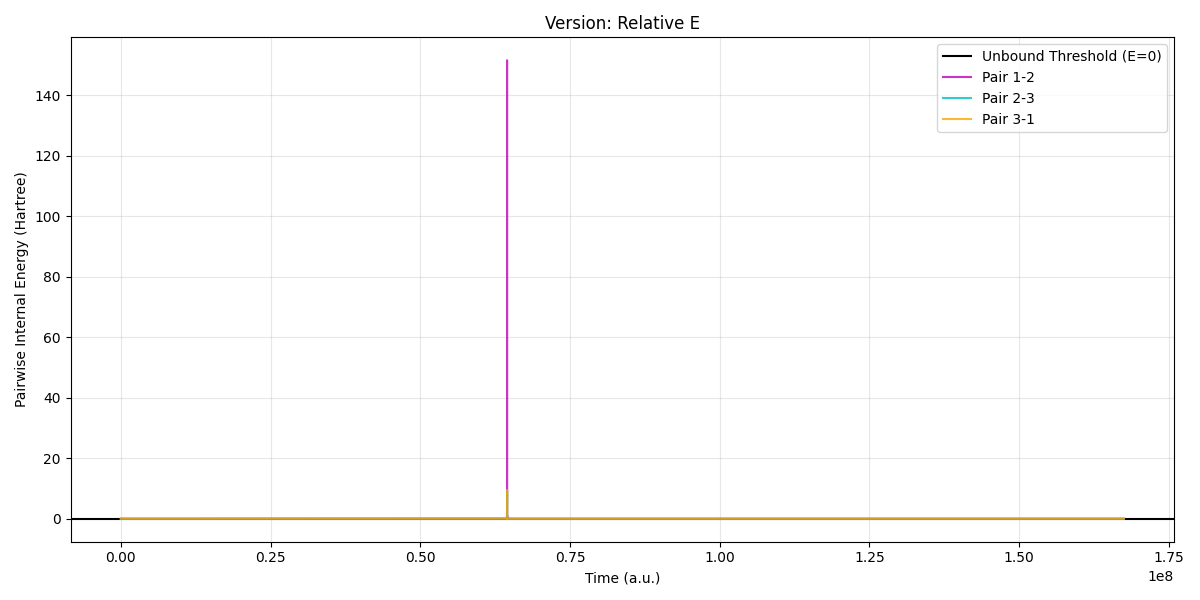

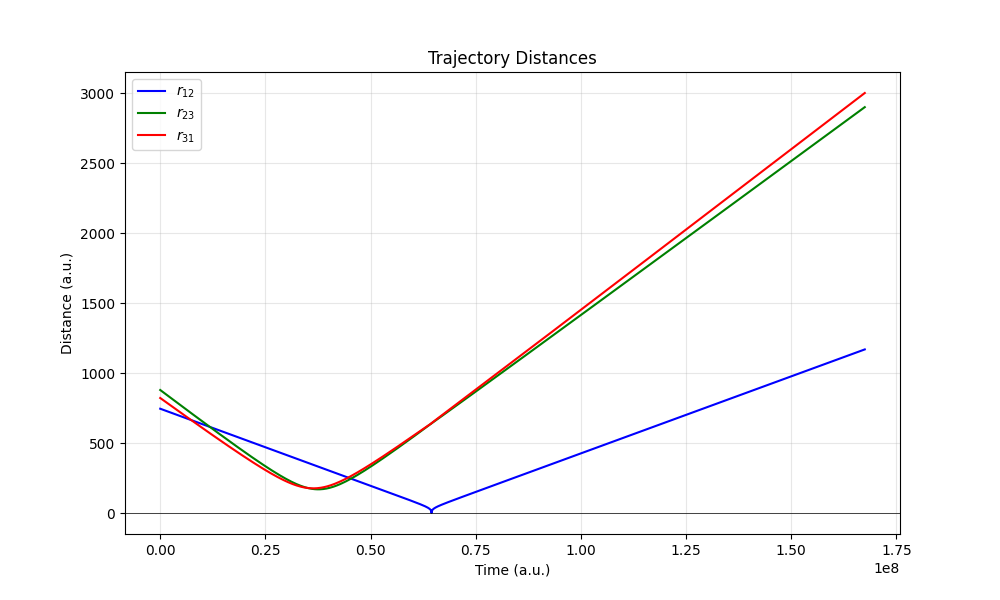

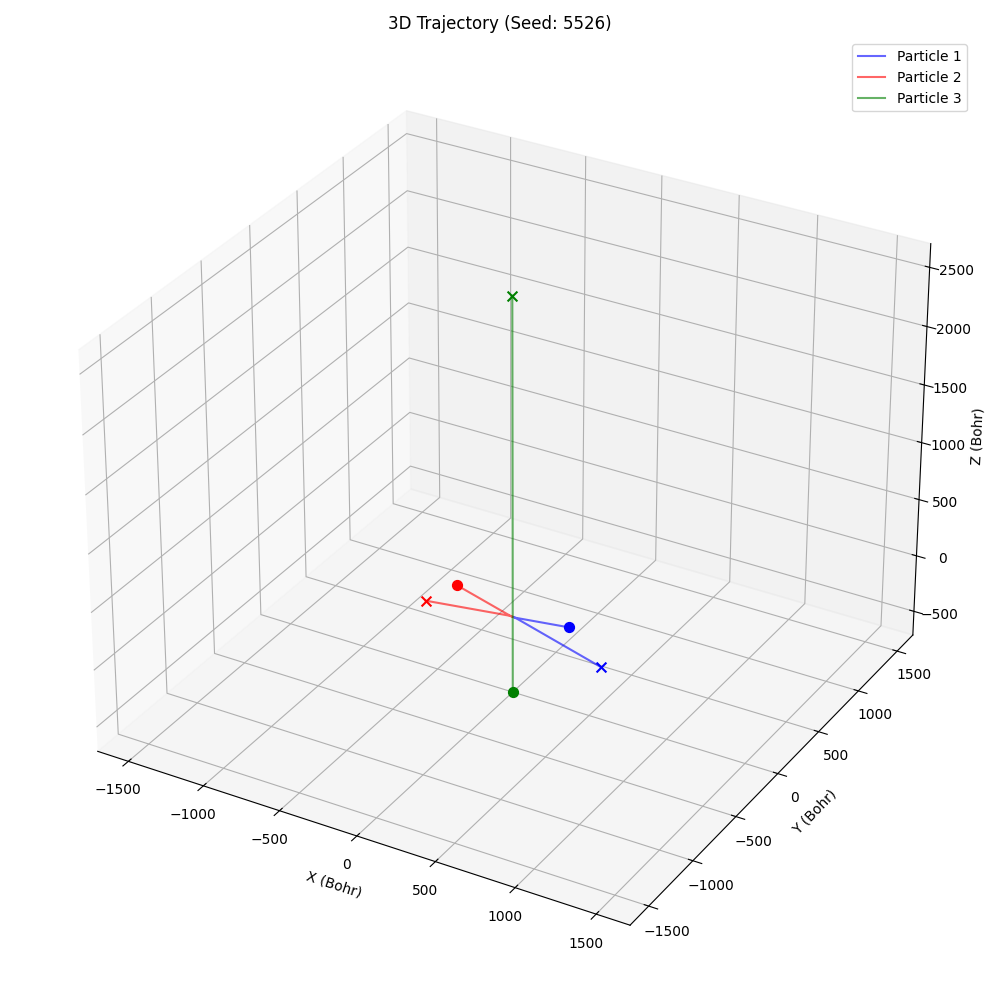

In [8]:
from tbr.simulator import get_distances_from_solution
from tbr.plotters import plot_distances, plot_3d_motion, plot_relative_e

# Observables
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

data_block = np.vstack([
            solution['times'], 
            r12, r23, r31,
            solution['positions_rho'], 
            solution['momenta_p']
        ]).T

print(n_res)
print(rho_vec)
plot_distances(data_block, seed, E0, b0)
# plot_2d_motion(data_block, seed)
plot_3d_motion(data_block, m1, m2, m3, seed)
plot_relative_e(solution, masses, v_funcs)
# plot_energy_trace(solution, masses, v_funcs)
# animate_3d_forces(solution, masses, dv_funcs, scale = 0,
#                   filename='trajectory_forces7.gif', duration_seconds=10,
#                   azim=0,elev=30)
plt.show()

Running trajectory with seed 28987...
Energy drift 2.3948517912840227e-11 Hartree
Trajectory run in 0.5716917514801025 s
Running trajectory with seed 24788...
Energy drift 2.3873543340391363e-11 Hartree
Trajectory run in 0.6869049072265625 s
Running trajectory with seed 24284...
Energy drift 2.4336891764520943e-11 Hartree
Trajectory run in 0.5572772026062012 s
Running trajectory with seed 29047...
Energy drift 2.3803126259631902e-11 Hartree
Trajectory run in 0.6192276477813721 s
Running trajectory with seed 31668...
Energy drift 2.342272109740731e-11 Hartree
Trajectory run in 0.5441670417785645 s
Running trajectory with seed 27228...
Energy drift 2.3419185712328545e-11 Hartree
Trajectory run in 0.549614429473877 s
Running trajectory with seed 28553...
Energy drift 2.415148111475961e-11 Hartree
Trajectory run in 0.489149808883667 s
Running trajectory with seed 26660...
Energy drift 2.3886179834872777e-11 Hartree
Trajectory run in 0.48296570777893066 s
Running trajectory with seed 25685.

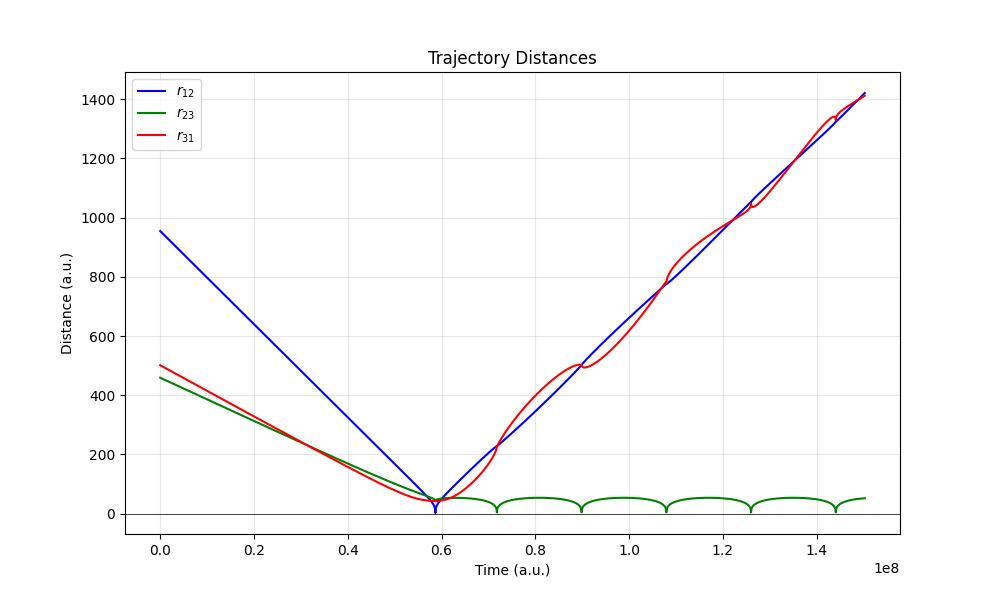

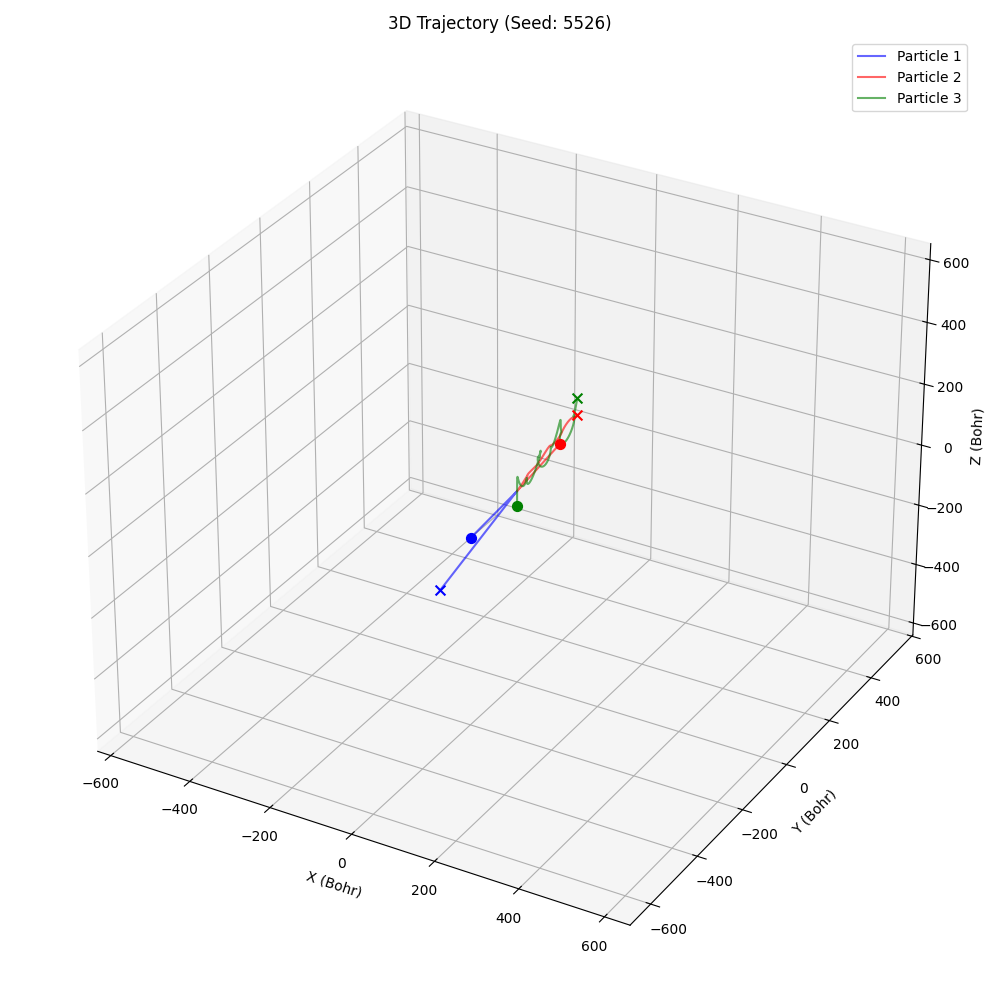

In [12]:
# Simulate until a reaction is found. 
masses = (2*14.007, 2*14.007, 4.0026) # N2, N2+, He
m1, m2, m3 = masses
E0 = 1 # Kelvin
R0 = 1000.0
dR0 = 0.1*R0
b0 = 0

def run_t():
    seed = int(np.random.random()*8923) + 23013
    print(f'Running trajectory with seed {seed}...')
    task_data = m1, m2, m3, E0, b0, R0,  v_funcs, dv_funcs, seed
    t0 = time.time()
    solution = run_trajectory_worker(task_data=task_data)
    tf = time.time()
    print(f'Trajectory run in {tf-t0} s')
    
    return solution

solution = run_t()
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']
n_t = 0
while (n_res[3] == 1) & (n_t < 100): # search for non-dissociative trajectories 
    solution = run_t()
    n_res = solution['n_res']
    times = solution['times']
    rho_vec = solution['positions_rho']
    p_vec = solution['momenta_p']
    n_t+=1

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

data_block = np.vstack([
            solution['times'], 
            r12, r23, r31,
            solution['positions_rho'], 
            solution['momenta_p']
        ]).T
print(n_res)
plot_distances(data_block, seed, E0, b0)
# plot_2d_motion(data_block, seed)
plot_3d_motion(data_block, m1, m2, m3, seed)
# plot_relative_e(solution, masses, v_funcs)
# plot_energy_trace(solution, masses, v_funcs)
# animate_3d_forces(solution, masses, dv_funcs, scale = 0,
#                   filename='trajectory_forces7.gif', duration_seconds=10,
#                   azim=0,elev=30)
# plt.show()

In [13]:
import seaborn as sns

def plot_opac(df, energies, suffix='BB', fmt = '.', label = None, save_path=None):
    # plt.figure()
    # colors = plt.cm.viridis(np.linspace(0,1,len(energies)))
    
    colors = sns.color_palette('deep', len(energies))

    for i, e_val in enumerate(energies):
        subset = df[df['e'] == e_val].sort_values('b')

        if subset.empty:
            print(f'Skipping E = {e_val}: No data found.')
            continue
        
        plt.errorbar(subset['b'], subset[f'p_{suffix}'], yerr=subset[f'p_{suffix}_err'],
                        fmt = fmt, capsize=3, label=f'{label}, E = {e_val} K', color = colors[i])
        
        if f'bmax_{suffix}' in df.columns:
            bmax = df[df['e'] == e_val].sort_values('b')[f'bmax_{suffix}'].values[0]
            plt.axvline(bmax, 0, 1, color = colors[i])
    
    plt.xlabel('Impact Parameter ($a_0$)')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout
    if save_path:
        plt.savefig(save_path)
        print(f'Plot saved: {save_path}')

In [17]:
from tbr.analysis import opacity, cross_section, rate
from tbr.constants import U2ME

in_file = 'results/n4_short.txt'

masses = (2*14.007, 2*14.007, 4.0026) # N2, N2+, He
reactants = ['N2', 'N2+', 'He'] # or ['A', 'B', 'C']
# reactants = ['A', 'A', 'A']
m1, m2, m3 = masses
mu0 = np.sqrt(m1*m2*m3/(m1+m2+m3))
m12 = m1*m2/(m1+m2)
tolerance_numerator = 10
window_size = 3
tolerances = {'AA': 10, 'AB': 38}
windows = {'AA': 3, 'AB': 3}

opac = opacity(in_file, reactants)
sigma = cross_section(opac, reactants, tolerances=tolerances, windows=windows)
k3 = rate(opac, mu0, reactants, windows=windows, tolerances=tolerances)

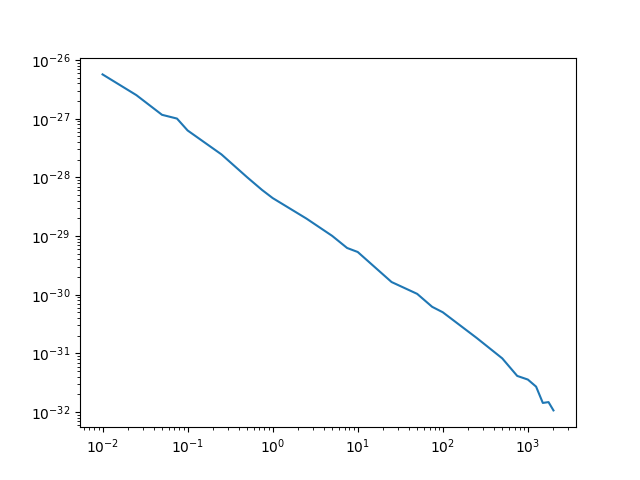

In [18]:
plt.figure()
plt.plot(k3['e'], k3['k_AB'])
# plt.plot(k3['e'], k3['k_BC'])
# plt.plot(k3['e'], k3['k_AC'])
plt.xscale('log')
plt.yscale('log')

Text(0, 0.5, 'Rate (cm$^6$/s)')

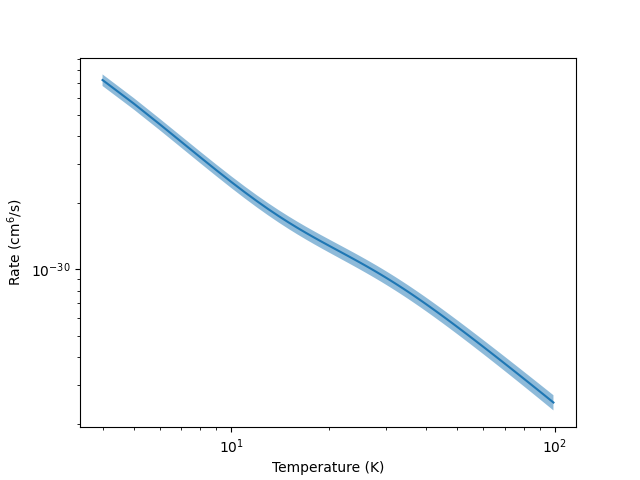

In [21]:
from tbr.analysis import thermal_rate
t_vals = np.arange(4, 100, 1)
tr = thermal_rate(k3, t_vals, 'AB')
plt.figure()
plt.plot(tr['T_K'], tr['k_thermal_AB'])
plt.fill_between(tr['T_K'], 
                 tr['k_thermal_AB'] - tr['k_thermal_AB_err'], tr['k_thermal_AB'] + tr['k_thermal_AB_err'],
                 alpha = 0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel(r'Rate (cm$^6$/s)')